Using percentiles :

In [10]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
#importing dataframe
df=pd.read_csv('weight-height.csv')

In [9]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x196f615b4d0>,
 'caps': [<matplotlib.lines.Line2D at 0x196f6215e50>,
 'boxes': [<matplotlib.lines.Line2D at 0x196f6159a90>],
 'medians': [<matplotlib.lines.Line2D at 0x196f62160d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x196f6216210>],
 'means': []}

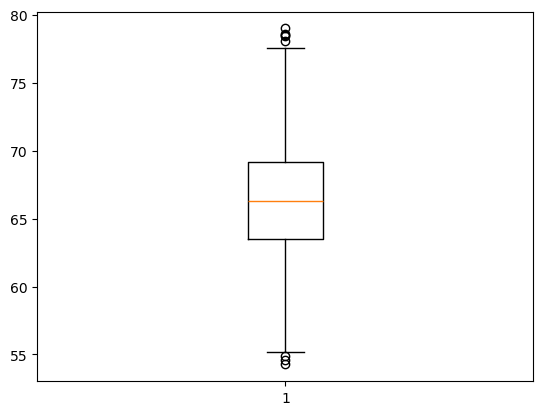

In [11]:
plt.boxplot(df['Height'])

In [12]:
upper_limit=df['Height'].quantile(0.99)
lower_limit=df['Height'].quantile(0.01)

In [15]:
outliers=df[(df['Height']>=upper_limit)|(df['Height']<=lower_limit)]
outliers.shape

(200, 3)

Trimming:

In [18]:
new_df=df[(df['Height']<=upper_limit)&(df['Height']>=lower_limit)]
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [19]:
new_df.describe()

,Height,Weight
count,9800.000000,9800.000000
mean,66.364366,161.399489
std,3.645075,30.933549
min,58.134496,77.523774
25%,63.577162,136.322717
50%,66.318070,161.212928
75%,69.119896,186.753317
max,74.785714,249.946283


{'whiskers': [<matplotlib.lines.Line2D at 0x196f63179d0>,
 'caps': [<matplotlib.lines.Line2D at 0x196f6317c50>,
 'boxes': [<matplotlib.lines.Line2D at 0x196f6317890>],
 'medians': [<matplotlib.lines.Line2D at 0x196f6317ed0>],
 'fliers': [<matplotlib.lines.Line2D at 0x196f6338050>],
 'means': []}

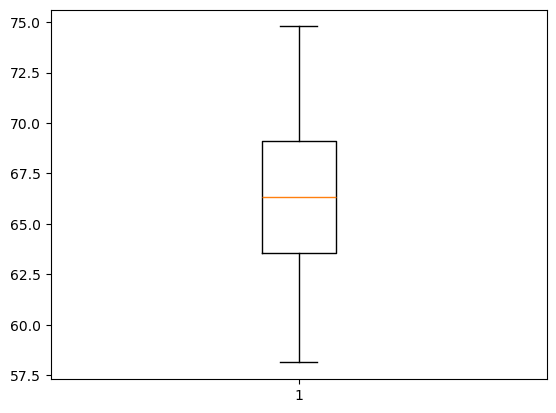

In [20]:
plt.boxplot(new_df['Height'])

Winsorization : (capping)

In [ ]:
winsor=df.copy()
winsor['Height']=np.where(
    df['Height']>=upper_limit,
    upper_limit,
    np.where(
        df['Height']<=lower_limit,
        lower_limit,
        df['Height']
    )
)
winsor.sample(5)

,Gender,Height,Weight
6432,Female,68.365438,153.742635
7837,Female,63.704201,133.023857
2987,Male,68.854857,196.719284
6735,Female,60.315045,111.974874
1891,Male,68.792051,197.679446


{'whiskers': [<matplotlib.lines.Line2D at 0x196fb8b7c50>,
 'caps': [<matplotlib.lines.Line2D at 0x196fb8b7ed0>,
 'boxes': [<matplotlib.lines.Line2D at 0x196fb8b7b10>],
 'medians': [<matplotlib.lines.Line2D at 0x196fb8f0190>],
 'fliers': [<matplotlib.lines.Line2D at 0x196fb62f9d0>],
 'means': []}

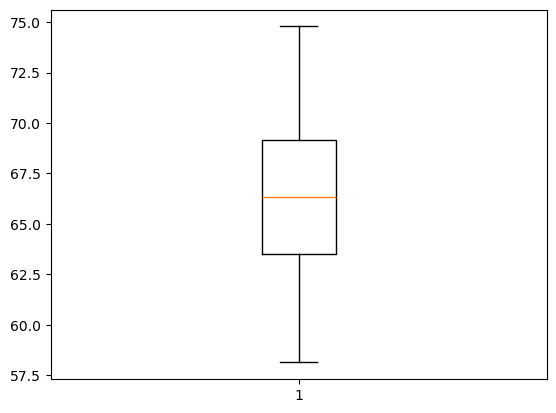

In [29]:
plt.boxplot(winsor['Height'])